<a href="https://colab.research.google.com/github/Valedulu/greends-ml-assigment_1/blob/main/wine_quality_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Wine Quality Regression

The goal of this notebook is to train a regression model to predict wine quality from its chemical properties, using the [Wine Quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality).

Dataset: 4898 white wine examples, 11 chemical features, quality score as the target.

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## 2. Load the data

We load the white wine CSV directly from the UCI repository.

- **Input**: the 11 chemical features (fixed acidity, volatile acidity, citric acid, etc.)
- **Output**: the `quality` column — an integer score from 0 to 10

In [ ]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
df  = pd.read_csv(url, sep=';')

print(f'Dataset shape: {df.shape}')   # should be (4898, 12)
df.head()

Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


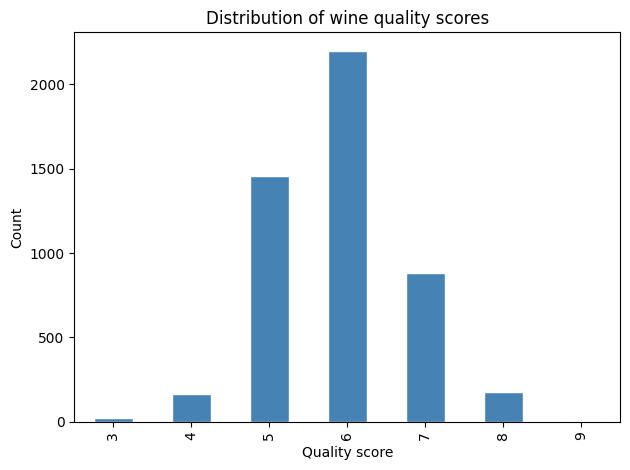

In [ ]:
# Quick look at the target distribution
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribution of wine quality scores')
plt.xlabel('Quality score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Split into train and test datasets

We split the data **before** any preprocessing. This is important — the test set must be completely independent of the training process.

- **Train dataset**: 80% of examples — used to fit the model weights
- **Independent test dataset**: 20% of examples — held out and only used at the end to evaluate the model. The model never sees this data during training.

In [ ]:
# Separate inputs (X) and output (y)
feature_cols = [c for c in df.columns if c != 'quality']

X = df[feature_cols].values   # shape (4898, 11)  ← inputs
y = df['quality'].values      # shape (4898,)     ← output

print(f'Inputs  X: {X.shape}  → {len(feature_cols)} features')
print(f'Output  y: {y.shape}  → quality score')
print(f'Features: {feature_cols}')

Inputs  X: (4898, 11)  → 11 features
Output  y: (4898,)  → quality score
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
# Manual 80/20 split (no sklearn, to keep it transparent)
np.random.seed(42)
indices   = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f'Train dataset : {X_train.shape[0]} examples')
print(f'Test  dataset : {X_test.shape[0]}  examples')

Train dataset : 3918 examples
Test  dataset : 980  examples


## 4. Feature scaling

The 11 features have very different scales (e.g. alcohol ≈ 8–14, free sulfur dioxide ≈ 1–72). Without scaling, gradient descent converges poorly — features with large values would dominate the weight updates.

We apply **standardization** (zero mean, unit variance), computed **only on the train set** and then applied to both train and test.

In [ ]:
# Compute mean and std from TRAINING data only
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_s = (X_train - X_mean) / X_std   # standardized train
X_test_s  = (X_test  - X_mean) / X_std   # same transform applied to test

print('Feature means (train):', np.round(X_mean, 2))
print('Feature stds  (train):', np.round(X_std,  2))

Feature means (train): [6.8600e+00 2.8000e-01 3.3000e-01 6.3700e+00 5.0000e-02 3.5240e+01
 1.3811e+02 9.9000e-01 3.1900e+00 4.9000e-01 1.0520e+01]
Feature stds  (train): [8.500e-01 1.000e-01 1.200e-01 5.100e+00 2.000e-02 1.698e+01 4.230e+01
 0.000e+00 1.500e-01 1.200e-01 1.230e+00]


## 5. The model — Linear Regression with SGD

We implement multiple linear regression from scratch using **Stochastic Gradient Descent (SGD)**.

- **Model**: `ŷ = w0 + w1·x1 + w2·x2 + ... + w11·x11`
- **Loss function**: Mean Squared Error — `MSE = (1/N) Σ (y - ŷ)²`
- **Batch**: one example at a time (that's what makes it *stochastic*)
- **Epoch**: one full pass through all examples in the train dataset

In [ ]:
class LinearRegression:
    """
    Multiple Linear Regression trained with Stochastic Gradient Descent.

    Model       : ŷ = w0 + w1·x1 + ... + wk·xk
    Loss        : MSE = (1/N) Σ (y - ŷ)²
    Batch size  : 1 example per weight update (SGD)
    """

    def __init__(self, learning_rate=0.0002, max_iter=200):
        self.lr       = learning_rate   # η — controls step size
        self.max_iter = max_iter        # number of epochs
        self.weights  = None            # w1 ... wk
        self.bias     = 0.0             # w0
        self.loss_history = []          # MSE recorded after each epoch

    def fit(self, X, y):
        """
        Train the model on the train dataset.
        X : (N, k) array of inputs
        y : (N,)   array of outputs
        """
        N, k = X.shape
        self.weights = np.zeros(k)   # initialise all weights to zero
        self.bias    = y.mean()  # start at mean for faster convergence
        self.loss_history = []

        for epoch in range(self.max_iter):              # ← epoch

            # shuffle examples each epoch for better SGD behaviour
            idx = np.random.permutation(N)

            for i in idx:                               # ← batch size = 1 (SGD)
                xi   = X[i]                             # one input example
                yi   = y[i]                             # its true output

                yhat  = self.bias + np.dot(self.weights, xi)   # predict
                error = yi - yhat                               # residual

                # gradient descent weight updates
                self.bias    += self.lr * error
                self.weights += self.lr * error * xi

            # record MSE loss at the end of each epoch
            epoch_preds = self.predict(X)
            mse = np.mean((y - epoch_preds) ** 2)      # ← loss function
            self.loss_history.append(mse)

            if (epoch + 1) % 10 == 0:
                print(f'  Epoch {epoch+1:>3}/{self.max_iter}  —  MSE: {mse:.4f}')

    def predict(self, X):
        """
        Make predictions on new data (can be train or test dataset).
        X : (N, k) array of inputs
        Returns predicted quality scores.
        """
        return self.bias + X @ self.weights

## 6. Train the model

We call `.fit()` on the **train dataset only**. The model will go through 200 epochs and print the MSE loss every 10 epochs so we can watch it decrease.

In [ ]:
np.random.seed(42)

model = LinearRegression(learning_rate=0.0002, max_iter=200)

print('Training on train dataset...\n')
model.fit(X_train_s, y_train)
print('\nDone.')

Training on train dataset...

  Epoch  10/200  —  MSE: 0.5603
  Epoch  20/200  —  MSE: 0.5585
  Epoch  30/200  —  MSE: 0.5577
  Epoch  40/200  —  MSE: 0.5572
  Epoch  50/200  —  MSE: 0.5569
  Epoch  60/200  —  MSE: 0.5567
  Epoch  70/200  —  MSE: 0.5564
  Epoch  80/200  —  MSE: 0.5564
  Epoch  90/200  —  MSE: 0.5562
  Epoch 100/200  —  MSE: 0.5563
  Epoch 110/200  —  MSE: 0.5562
  Epoch 120/200  —  MSE: 0.5561
  Epoch 130/200  —  MSE: 0.5560
  Epoch 140/200  —  MSE: 0.5560
  Epoch 150/200  —  MSE: 0.5560
  Epoch 160/200  —  MSE: 0.5561
  Epoch 170/200  —  MSE: 0.5561
  Epoch 180/200  —  MSE: 0.5560
  Epoch 190/200  —  MSE: 0.5560
  Epoch 200/200  —  MSE: 0.5559

Done.


## 7. Plot 1 — Loss vs Epochs

This plot shows how the **loss function** (MSE) decreases over **epochs** during training. The loss should drop quickly at first and then flatten as the model converges.

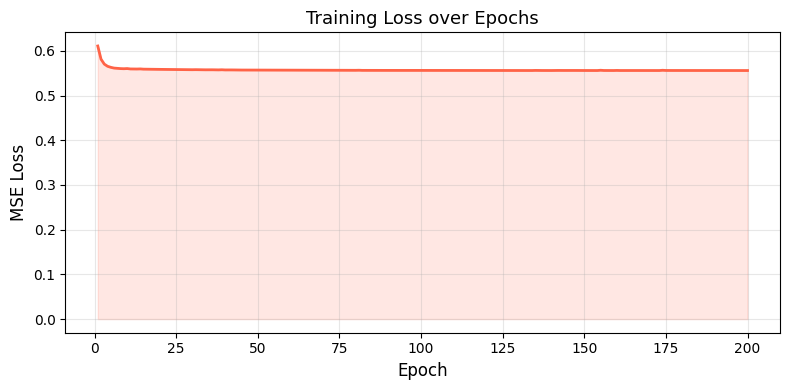

Initial MSE : 0.6108
Final   MSE : 0.5559


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(model.loss_history) + 1), model.loss_history,
         color='tomato', lw=2)
plt.fill_between(range(1, len(model.loss_history) + 1),
                 model.loss_history, alpha=0.15, color='tomato')

plt.xlabel('Epoch',    fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training Loss over Epochs', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_vs_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Initial MSE : {model.loss_history[0]:.4f}')
print(f'Final   MSE : {model.loss_history[-1]:.4f}')

## 8. Evaluate on the independent test dataset

Now we use `.predict()` on the **test dataset** — data the model has never seen. This gives an honest estimate of how well the model generalises.

In [ ]:
y_pred_train = model.predict(X_train_s)   # predictions on train
y_pred_test  = model.predict(X_test_s)    # predictions on independent test set

mse_train = np.mean((y_train - y_pred_train) ** 2)
mse_test  = np.mean((y_test  - y_pred_test)  ** 2)

print(f'Train MSE : {mse_train:.4f}')
print(f'Test  MSE : {mse_test:.4f}')
print()
print('If Test MSE >> Train MSE, the model may be overfitting.')
print(f'Difference: {abs(mse_test - mse_train):.4f}')

Train MSE : 0.5559
Test  MSE : 0.5937

If Test MSE >> Train MSE, the model may be overfitting.
Difference: 0.0378


## 9. Plot 2 — Actual vs Predicted values

This plot compares the true quality scores against the model's predictions on the **test dataset**. A perfect model would place all points on the diagonal line.

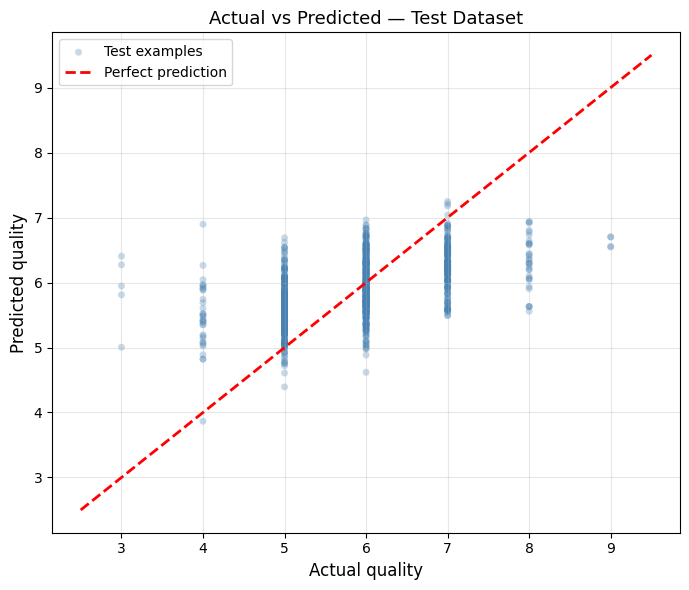

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_test,
            alpha=0.3, color='steelblue', edgecolors='none', s=25,
            label='Test examples')

# perfect prediction line
lo, hi = y_test.min() - 0.5, y_test.max() + 0.5
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect prediction')

plt.xlabel('Actual quality',    fontsize=12)
plt.ylabel('Predicted quality', fontsize=12)
plt.title('Actual vs Predicted — Test Dataset', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary

| Keyword | Where it appears in this notebook |
|---|---|
| **Input** | 11 chemical features in `X` |
| **Output** | `quality` score in `y` |
| **Model** | `LinearRegression` class — `ŷ = w0 + w1x1 + ... + w11x11` |
| **Loss function** | MSE computed each epoch inside `.fit()` |
| **Epoch** | One full pass through the train dataset (outer loop in `.fit()`) |
| **Batch** | 1 example per weight update (SGD — inner loop in `.fit()`) |
| **Predict** | `.predict()` method applied to test data |
| **Train dataset** | `X_train_s`, `y_train` — 80% of examples, used in `.fit()` |
| **Independent test dataset** | `X_test_s`, `y_test` — 20% of examples, never seen during training |